### Assignment 5: Comparative Binary Classification with XGBoost
**Name:** Ailibiya Kuerban
**Student ID:** 101039952

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Problem Definition

* Target variable: Bankrupt?
* Positive class: 1 (went bankrupt)
* Why it matters: missing a bankrupt company is worse than a false alarm
* Classes are imbalanced (~3.2% positive)
* Primary metric: PR-AUC
* Calibration metric: Brier score

In [4]:
df = pd.read_csv("../data/data.csv")

## 2. Quick EDA

#### 2.1 Dataset Overview


In [ ]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (6819, 96)
<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    Af

#### 2.2 Target Distribution


Class counts:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

Class percentages:
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


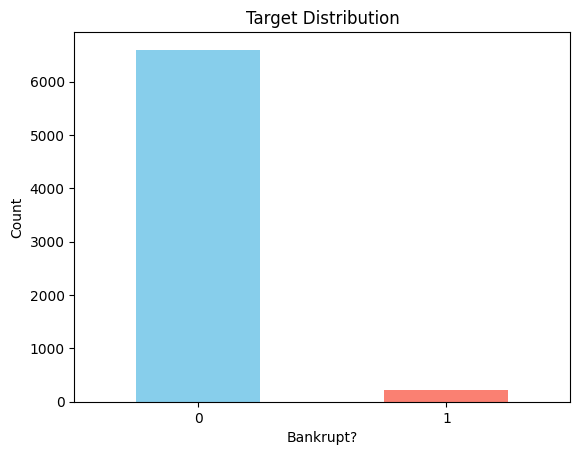

In [6]:
import matplotlib.pyplot as plt

class_counts = df["Bankrupt?"].value_counts().sort_index()
class_percentages = df["Bankrupt?"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))

class_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Target Distribution")
plt.xlabel("Bankrupt?")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


#### 2.3 Missing Values and Duplicates

In [7]:
missing_per_column = df.isnull().sum()
total_missing = df.isnull().sum().sum()
duplicate_count = df.duplicated().sum()

print("Missing values per column:")
print(missing_per_column)

print("\nTotal missing values:", total_missing)
print("Duplicate row count:", duplicate_count)


Missing values per column:
Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

Total missing values: 0
Duplicate row count: 0


#### 2.4 Key Observation for Modeling
* Only about 3% of companies are bankrupt, so accuracy will not be used as the primary metric.

## 3. Train, Validation, Test Split
* Train = 70%
* Validation = 15%
* Test = 15%
* Use stratified sampling
* Test set is not used until final evaluation

#### 3.1 Split Strategy


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# Print class distribution percentages
print("\nClass distribution in training set (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in validation set (%):")
print((y_val.value_counts(normalize=True) * 100).round(2))

print("\nClass distribution in test set (%):")
print((y_test.value_counts(normalize=True) * 100).round(2))


X_train shape: (4773, 95)
X_val shape: (1023, 95)
X_test shape: (1023, 95)

y_train shape: (4773,)
y_val shape: (1023,)
y_test shape: (1023,)

Class distribution in training set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Class distribution in validation set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64

Class distribution in test set (%):
Bankrupt?
0    96.77
1     3.23
Name: proportion, dtype: float64


#### 3.2 Why Stratified Sampling Is Used
* Stratified sampling is used to ensure that the class distribution of the target variable is preserved across the train, validation, and test sets. Since the dataset is highly imbalanced, this helps prevent situations where one split may contain too few or no positive cases, which would negatively affect model training and evaluation.

#### 3.3 Class Balance Across Splits

## 4. Preprocessing
* separate features (X) and target (y)
* remove target column from features
* check whether there are categorical features
* handle missing values if needed
* only scale models that need scaling
* briefly check for leakage columns

#### 4.1 Separate Features and Target


#### 4.2 Data Type Review


#### 4.3 Missing Value Handling


#### 4.4 Leakage Check


#### 4.5 Scaling Strategy
* Logistic Regression may need scaling
* XGBoost does not require scaling

## 5. Feature Sets

#### 5.1 Feature Set A
* all usable features after basic cleaning

#### 5.2 Feature Set B
* smaller selected feature set


#### 5.3 Feature Selection Method
* Feature Set B will be created using XGBoost feature importance
* Top 20–30 features will be selected

## 6. Evaluation Framework

#### 6.1 Primary Validation Metrics
* Validation PR-AUC
* Validation Brier score


#### 6.2 Secondary Metrics
* ROC-AUC
* precision
* recall
* F1-score or F2-score
* accuracy only as extra context

#### 6.3 Overfitting Check
* compare train PR-AUC and validation PR-AUC
* define overfit_gap = train_pr_auc - val_pr_auc

#### 6.4 Reusable Evaluation Function

## 7. Experiments 

#### 7.1 Experiment 1: Simple Baseline Model

#### 7.2 Experiment 2: XGBoost Baseline

#### 7.3 Experiment 3: XGBoost with Imbalance Handling

#### 7.4 Experiment 4: Lightly Tuned XGBoost

#### 7.5 Experiment 5: XGBoost with Selected Features

## 8. Required Metrics
* PR-AUC is used as the primary discrimination metric because it focuses on performance for the rare positive class. 
* Brier score is used to evaluate the quality of predicted probabilities. 
* Accuracy is not used as a primary metric due to class imbalance.

## 9. Threshold Selection

## 10. Results Table

## 11. Final Test Evaluation

## 12. Conclusion


## 13. AI Usage Statement